In [951]:
%config InlineBackend.figure_format = 'svg'

```{warning}
This chapter is still under construction. Errors may exist and significant changes may occur.
```

```{index} ChemPy
```
```{index} simulations
```
(18)=
# Chapter 18: ChemPy

The ChemPy library provides a collection of tools useful for general, physical, analytical, and inorganic chemistry. Examples include balancing chemical reactions, stoichiometric calculations, solving complex equilibria, and decomposing reducible symmetry representations. This package does not come with Anaconda installations and is not automatically included in [Colab](0.2.2), so you will need to install it using either `pip` or `conda`. See the most recent [package instructions](https://github.com/bjodah/chempy) for further details.

In [952]:
import numpy as np
import matplotlib.pyplot as plt

```{index} SMILES
```
```{index} InChI
```
(18.1)=
## 18.1 Formulas, Stoichiometry, and Equilibria

(18.1.1)=
### Chemical Formulas

Before we move into solving more complex problems, we first need to introduce a foundational object in ChemPy, which is the `Substance`. The `Substance` holds information about a chemical species including the chemical composition, mass, charge, etc. The substance holds information about the chemical substance that is always true. There is a also subclass called a `Species`, which inherits attributes from the `Substance` class but also allows phase information used in kinetics and equilibrium calculations. Both are imported as shown below.

In [953]:
from chempy import Substance, Species

The most basic way to create a `Substance` is using the `Substance()` function, which accepts a number of parameters including the following. These are keyword arguments, but the `name` is frequently just supplied as the first positional argument.

**Table 1** `Substance()` Parameters 

| Parameter | Type | Description |
|:---------:|:------:|:--------------|
| `name` | `str` | Name of substance |
| `composition` | `dict` | Elemental composition |
| `charge` | `int` | Overall net charge | 
| `data` | `dict` |  Dictionary with user-defined keys |

In the example below, we create an ammonia substance. No parameters are required when a `Substance` is created, but including some attributes is helpful for later calculations. Below, we will include the elemental composition of ammonia using a dictionary with the element's atomic number as the keys. For example, ammonia has one nitrogen atom (AN = 7) and three hydrogen atoms (AN = 1).

In [954]:
NH3 = Substance('NH3', composition={7: 1, 1: 3})

Alternatively, you can create a `Substance` object using the `from_formula` constructor. This function parses a string molecular formula of the chemical substance and uses it to populate the name and composition of the `Substance`.

In [955]:
sulf = Substance.from_formula('Na2SO4')
sulf.name

'Na2SO4'

In [956]:
sulf.composition

{8: 4, 11: 2, 16: 1}

In [957]:
sulf.charge

0

The charge defaults to 0 unless a charge is included in the formula. It is important to note that the charge needs to be written with the sign first. That is, +2, not 2+.

In [958]:
nitrate = Substance.from_formula('NO3-')
nitrate.charge

-1

In [959]:
copper = Substance.from_formula('Cu2+2')
copper.charge

2

Once a `Substance` has been created, we can use it to calculate the mass of the substance as demonstrated below.

In [960]:
sulf.mass

142.03553856000002

Additional information can be included in the `data` attribute using a dictionary with user-defined keys. Below, we include the boiling point of benzene.

In [961]:
benzene = Substance('C6H6', data={'bp': 80})
benzene.data

{'bp': 80}

So far, this isn't really doing much for us, but we will be using these `Substance` objects throughout this chapter to solve various chemical problems.

(18.1.2)=
### 18.1.2 Stoichiometry

ChemPy includes the ability to balance chemical reactions using the `balance_stoichiometry()` function. This function accepts two list, sets, or tuples - the first being reactants and the second products. The function returns two ordered dictionaries (`OrderedDict`), which for our purposes operate like regular Python dictionaries. The keys are the chemical species name and the value is the stoichiometric coefficient for the balanced reaction.

In [962]:
from chempy import balance_stoichiometry

In [963]:
r, p = balance_stoichiometry(['Cu', 'HNO3'], ['Cu(NO3)2', 'NO', 'H2O'])
r

OrderedDict([('Cu', 3), ('HNO3', 8)])

In [964]:
p

OrderedDict([('Cu(NO3)2', 3), ('NO', 2), ('H2O', 4)])

In [965]:
r['Cu']

3

In [966]:
balance_stoichiometry({'P4', 'OH-', 'H2O'}, {'PH3', 'H2PO4-'})

(OrderedDict([('H2O', 9), ('OH-', 3), ('P4', 2)]),
 OrderedDict([('H2PO4-', 3), ('PH3', 5)]))

(18.1.3)=
### 18.1.3 Calculating Theoretical Yields

The ChemPy library does not include an explicit function to calculate the limiting reactant or theoretical yield, but a short Python script can be written leveraging the above functionality. As our example, we will use the oxidation of nitrogen monoxide to nitrogen dioxide: NO(g) + O$_2$(g) $\rightarrow$ NO$_2$(g).

To carry out this calculation, we will use the following equations where $\xi$(xi) is the **extent of reaction**, $n_i$ is the initial moles of a chemical species, $n_f$ is the final moles of a chemical species, and $\nu$ is the coefficient of that species in the balanced reaction with positive for products and negative for reactants. The extent of reaction is how many moles a chemical speices changes in the reaction divided or normalized by the stoichiometric coefficient. ChemPy will contribute to our calculations by balancing the chemical reaction and calculating the molecular weight from the formulas. 
$$ n_f = n_i + \nu\xi $$

First, the mass of each chemical species is provided in a list of two dictionaries, reactants first then products.

In [967]:
grams = [{'NO': 3.01, 'O2': 2.83}, {'NO2': 0.0}]

Next, we will have ChemPy balance the reaction. To automate as much as possible, the following list comprehensions extract the reactants and products from the dictionaries above. It is assumed that the user included all chemical species, even those with zero starting mass.

In [968]:
react, prod = balance_stoichiometry([key for key in grams[0].keys()], 
                                    [key for key in grams[1].keys()])

Next, we convert the mass of each species to the moles, leveraging ChemPy's ability to calculate molecular masses. We also calculate the extend of reaction, $\xi$(xi), by dividing all moles of reactants by their stoichiometric coefficients and finding the smallest value, which corresponds to the limiting reactant.

In [969]:
mol_r = {spec: g / Substance.from_formula(spec).mass for spec, g in grams[0].items()}
xi = min(mol_r[spec] / react[spec] for spec in react.keys())

Finally, we calculate the final mass and moles of products and reactants using the equation shown above. This results in two dictionaries containing the names of the species with the masses as the final values.

In [970]:
prod = {spec: xi * mol * Substance.from_formula(spec).mass for spec, mol in prod.items()}
react = {spec: grams[0][spec] - xi * mol * Substance.from_formula(spec).mass for spec, mol in react.items()}

In [971]:
prod

{'NO2': 4.61491201759648}

In [972]:
react

{'NO': 0, 'O2': 1.22508798240352}

We can also package this into a single Python function which accepts the starting grams of reactant and product in dictionaries.

In [973]:
def calc_grams(grams_r, grams_p):
    """Calculates final grams of products and reactants.

    Parameters
    ----------
    grams_r : dict
        Dictionary with reactant names (str) as keys and starting grams of
        reactants (float) as values.
    grams_p : dict
        Dictionary with product names (str) as keys and starting grams of
        product (float) as values.
        
    Returns
    -------
    react : dict
        Dictionary with reactant names (str) as keys and final grams of
        reactants (float) as values.
    prod : dict
        Dictionary with product names (str) as keys and final grams of
        product (float) as values.
        
    """
    react, prod = balance_stoichiometry([key for key in grams_r.keys()], 
                                 [key for key in grams_p.keys()])

    mol_r = {spec: g / Substance.from_formula(spec).mass for spec, g in grams_r.items()}
    xi = min(mol_r[spec] / react[spec] for spec in react.keys())
    prod = {spec: grams_p[spec] + xi * mol * Substance.from_formula(spec).mass 
            for spec, mol in prod.items()}
    react = {spec: grams_r[spec] - xi * mol * Substance.from_formula(spec).mass 
             for spec, mol in react.items()}

    return react, prod

In [974]:
calc_grams({'C6H12O6': 25, 'O2': 40}, {'CO2': 0.0, 'H2O': 0.0})

({'C6H12O6': 0, 'O2': 13.3580896556318},
 {'CO2': 36.6424099114101, 'H2O': 14.9995004329581})

In [975]:
calc_grams({'TiCl4': 1000, 'Mg': 200}, {'Ti': 0.00, 'MgCl2': 0.00})

({'TiCl4': 219.637934581362, 'Mg': 0},
 {'Ti': 196.943015840362, 'MgCl2': 783.419049578276})

(18.2)=
## 18.2 Kinetic Simulations

ChemPy can also simulate chemical kinetics by integrating ordinary differential equations. While this topic has been covered in [section 9.1.4](9.1.4), the advantage of ChemPy is that it builds the differential equations for the user. This means the user only needs to provide the reactions and rate constants as strings along with providing the initial concentrations and times at which to simulate the concentrations. As an example, we will simulate the following hypothetical reactions with rate constants.

$$ 2 NO + O_2 \rightarrow 2 NO_2, \quad k_1 = 2.1\times10^6 $$
$$ NO + NO_2 \rightarrow N_2O_3, \quad k_2 = 1.1\times10^9 $$
$$ N_2O_3 \rightarrow NO + NO_2, \quad k_{-2} = 4.3\times10^6 $$

We will first need to import the `ReactionSystem()` and `get_odesys()` functions.

In [976]:
from chempy import ReactionSystem
from chempy.kinetics.ode import get_odesys

We then need to react the reaction system. There are multiple ways of doing this, but the simplest is to provide the reactions and rate constants as strings using the `from_string()` method. We also need to make a list or array of times at which to calculate the concentrations during the course of the chemical reaction (`times`). Finally, we need to create a dictionary with all of the starting concentrations (`C0`).

In [977]:
react_sys = ReactionSystem.from_string("""2 NO + O2 -> 2 NO2; 2.1e6
                                          NO + NO2 -> N2O3; 4.7e9
                                          N2O3 -> NO + NO2; 4.3e6""")
times = np.linspace(0, 20, 200)
C0 = {'NO': 1.0e-3, 'O2': 8.0e-4, 'NO2': 0.0, 'N2O3': 0.0}

The reaction system is fed into the `get_odesys()` function. Finally, the `integrate()` method is applied to the `odesys` to perform the actual integration. The `integrate()` function requires the times (`times`) and initial concentrations (`C0`).

In [978]:
odesys, _ = get_odesys(react_sys)
results = odesys.integrate(times, C0)

The integration results can be accessed with the following attributes. The concentrations (`yout`) are in same order as the names (`names`).

**Table 2** Integration Results Attributes
| Attribute | Type | Description |
|:---------:|:------:|:--------------|
| `names` | `str` | Name of substance |
| `xout` | `np.array` | Times integrated at |
| `yout` | `np.array` | Concentrations over course of reaction| 

In [979]:
results.names

('N2O3', 'NO', 'NO2', 'O2')

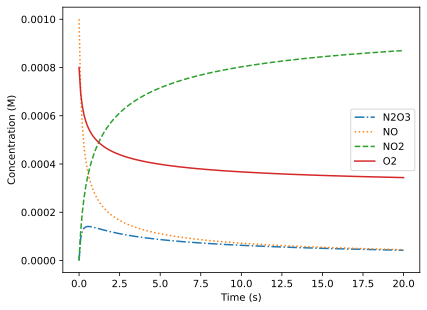

In [980]:
plt.plot(results.xout, results.yout[:, 0], linestyle='dashdot', label=results.names[0])
plt.plot(results.xout, results.yout[:, 1], linestyle='dotted', label=results.names[1])
plt.plot(results.xout, results.yout[:, 2], linestyle='dashed', label=results.names[2])
plt.plot(results.xout, results.yout[:, 3], linestyle='solid', label=results.names[3])
plt.xlabel('Time (s)')
plt.ylabel('Concentration (M)')
plt.legend();

```{index} defaultdict
```
As you simulate longer mechanisms, you will likely find yourself creating the initial concentration dictionary with a large number of `0.00` values because everything except reactants have zero concentration.  To make this task easier, Python has **defaultdict** object, which is essentially a Python dictionary that returns a default value for anything not defined in the dictionary. For floats, the default is `0.0`, for integers, it is `0`, and for strings, it is `''` (i.e., empty string). To use the defaultdict object, import it from the collections module and then give the `defaultdict(type, dict)` a default object type and a dictionary with the values you do want to define.

In our above example, the `C0` dictionary can be replaced by the one below.

In [981]:
from collections import defaultdict

C0 = defaultdict(float, {'NO': 1.0, 'O2': 0.8})

In [982]:
C0['NO']

1.0

In [983]:
C0['NO2']

0.0


(18.3)=
## 18.3 Solving Equilibria

Solving for equilibrium concentrations is a tedious, multistep calculation if performed by hand and can involve solving polynomials or making approximations. Solving for equilibrium concentrations of tandem equilibria is even more challenging. ChemPy provides tools for solving these problems, including complex, tandem equilibria. We must first perform the following imports.

In [984]:
from chempy import Equilibrium
from chempy.equilibria import EqSystem

The `Equilibrium` object defines a single equilibrium with the reactants, products, stoichiometry, and equilibrium constant.  The chemical species are provided as the keys in dictionaries with the coefficients as the dictionary values. As usual, the reactant dictionary comes before the product dictionary. Finally, the equilibrium constant is included as the third positional argument.

~~~python
Equilibrium(react_dict, prod_dict, Keq)
~~~


The `EqSystem` object holds one or more `Equilibrium` object as a list or tuple followed by all chemical species in the form of a `Substance` object.

Below, we demonstrate this with decomposition of ammonia to nitrogen and hydrogen gas.

$$ 2 NH_3 \rightleftharpoons N_2 + 3 H_2 $$

We first define each chemical species as a `Substance`. Be sure to include the name since this will be used by ChemPy to connect each `Substance` with the species various dictionaries. Next, the `Equilibrium` object is created. The first dictionary describes the stoichiometry of all reactants, the second dictionary describes the stoichiometry of all products, and the third positional argument is the equilibrium constant for this equilibrium as written. The equilibrium system (`EqSystem`) is created by providing all equilibria as a list or tuple followed by all `Substance` objects as a list or tuple. Even if there is only one equilibrium, it still needs to be packaged in a list or tuple.

In [985]:
NH3 = Substance.from_formula('NH3')
N2  = Substance.from_formula('N2')
H2  = Substance.from_formula('H2')

eq = Equilibrium({'NH3': 2}, {'N2': 1, 'H2': 3}, 3.44)
eqsys = EqSystem([eq], [NH3, N2, H2])

To solve the equilibrium, we used the `root()` method on the `EqSystem` object, and the `root()` method requires the initial concentrations of all species as a dictionary. Be sure the names of all chemical species match those in your `Substance` objects above. This is how ChemPy knows they are the same chemical species. 

There are three outputs from this calculation listed below. The first one is really what most people are interested in.
1. x - The equilibrium concentrations of all species in the order provided to the `EqSystem()` function
2. sol - Output from the `scipy.optimize.root` solver for those who are interested.
3. sane - This is a boolean that the result is reasonable (i.e., non-negative concentrations and mass balance

In [986]:
C0 = {'NH3': 0.6, 'N2': 0.0, 'H2': 0.6}
x, sol, sane = eqsys.root(C0)

In [987]:
x

array([0.25998632, 0.17000684, 1.11002052])

In [988]:
sane

True

As a more complex example, we will solve the following iron/thiocyanate tandem equilibrium where $K_1$ = 890 and $K_2$ = 2.6.

$$ Fe^{3+}(aq) + SCN^{1-}(aq) \quad {\stackrel{K_1}{\rightleftharpoons}} \quad [Fe(SCN)]^{2+}(aq)  $$
$$ [Fe(SCN)]^{2+}(aq) + SCN^{1-}(aq) \quad {\stackrel{K_2}{\rightleftharpoons}} \quad [Fe(SCN)_2]^{1+}(aq)  $$

In [989]:
Fe = Substance.from_formula('Fe+3')
SCN  = Substance.from_formula('SCN-')
FeSCN = Substance.from_formula('Fe(SCN)+2')
FeSCN2 = Substance.from_formula('Fe(SCN)2+1')

eq_1 = Equilibrium({'Fe+3': 1, 'SCN-': 1}, {'Fe(SCN)+2': 1}, 890)
eq_2 = Equilibrium({'Fe(SCN)+2': 1, 'SCN-': 1}, {'Fe(SCN)2+1': 1}, 2.6)

eqsys = EqSystem([eq_1, eq_2], [Fe, SCN, FeSCN, FeSCN2])
C0 = defaultdict(float, {'Fe+3': 1.0 , 'SCN-': 2.0})

x, sol, sane = eqsys.root(C0)

In [990]:
x

array([0.00111811, 0.45811688, 0.45588066, 0.54300123])

We can test that the solution is valid in terms of the equilibrium by calculating the reaction quotient for each equilibrium, and we find that they match both equilibrium constants.

In [991]:
x[2] / (x[0] * x[1])

np.float64(889.9999999999998)

In [992]:
x[3] / (x[2] * x[1])

np.float64(2.6)

For a valid solution, we also need mass to be conserved, which is tested automatically by ChemPy.

In [1014]:
sane

True

(18.4)=
## 18.4 Symmetry

Molecular symmetry is important to chemistry in a variety of applications including bonding, chirality, electronic transitions, and chemical spectroscopy to name a few. While chemists frequently apply symmetry on a qualitative level, group theory can be used as a more rigorous, quantitative treatment of the subject. While the application of group theory to chemistry is a very powerful tool, it often involves an onerous amount of matrix math (i.e., linear algebra) when done by hand. These are the kind of calculations that computers are exceptionally well suited at. The `chempy.symmetry` module includes tools specifically to carry out these types of calculations such as decomposing (i.e., reducing) reducible representations, predicting IR- and Raman-active vibrational modes, generating reducible representations for all motions, and generating symmetry-adapted linear combinations (SALCs) of atomic orbitals among others. In this section, we will examine a few of these features for removing some of the tedium from group theory calculations.

The `chempy.symmetry` module has two submoules, `representations` and `salcs`. The `representations` module works with reducible and irreducible representations and vibrational predictions while the `salcs` module predicts SALCs by either the projection operator method or using the symmetry functions in character tables. We will address both here.

(18.4.1)=
### 18.4.1 Symmetry Representations

The first module in the `chempy.symmetry` module is `representations`, which works with interconverting reducible and irreducible representations, generating reducible representations, and predicting vibrational modes as a result of these representations. 

In [993]:
import chempy.symmetry.representations as reps

The main object in the `representations` module is a reducible representation creating using the `Reducible()` function. This requires the values (`gamma`) provided as a list, tuple, or array followed by the point group name (`group`) as a string. The `all_motion=` keyword argument is set to `True` if the reducible representation is for all motions (i.e., rotation, vibration, and translation) and `False` if it represents vibrations. The default is `False`.

The `gamma` attribute returns the $\Gamma$ values.

The following example is all motions of water.

In [994]:
reduc = reps.Reducible([9, -1, 3, 1], 'c2v', all_motion=True)
reduc.gamma

[9, -1, 3, 1]

In [995]:
reduc.all_motion

True

Use the `decomp()` method to decompose or reduce the reducible representation. The number of each irreducible representation for that point group is returned in the order in the character table.

In [996]:
reduc.decomp()

array([3, 1, 3, 2])

If you don't have a character table available, you can use the `print_table()` function to print character table.

In [997]:
reps.print_table('c2v')

╭─────┬───┬────┬────┬─────╮
│ C2v │ E │ C₂ │ σv │ σvʹ │
├─────┼───┼────┼────┼─────┤
│ A1  │ 1 │ 1  │ 1  │ 1   │
├─────┼───┼────┼────┼─────┤
│ A2  │ 1 │ 1  │ -1 │ -1  │
├─────┼───┼────┼────┼─────┤
│ B1  │ 1 │ -1 │ 1  │ -1  │
├─────┼───┼────┼────┼─────┤
│ B2  │ 1 │ -1 │ -1 │ 1   │
╰─────┴───┴────┴────┴─────╯


Alternatively, if the `decomp()` parameter `to_dict` is set to `True`, the number of each irreducible representation is returned as a dictionary, which is often more interpretable than the default NumPy array.

In [998]:
reduc.decomp(to_dict=True)

{'A1': 3, 'A2': 1, 'B1': 3, 'B2': 2}

To predict the IR- and Raman-active modes, use the `ir_active()` and `raman_active()` methods, which also accept the optional `to_dict=` argument.

In [999]:
reduc.ir_active(to_dict=True)

{'A1': 2, 'A2': 0, 'B1': 1, 'B2': 0}

In [1000]:
reduc.raman_active(to_dict=True)

{'A1': 2, 'A2': 0, 'B1': 1, 'B2': 0}

Likewise, the vibrational modes can be predicted using the `vibe_modes()` function. In this water example, all vibrational modes happen to be both IR- and Raman-active.

In [1001]:
reduc.vibe_modes(to_dict=True)

{'A1': 2, 'A2': 0, 'B1': 1, 'B2': 0}

(18.4.2)=
### 18.4.2 Reducible Representations for All Motions

The generation of a reducible representation for all motions is often a tedious and challenging task for molecules that lie nicely on the Cartesian axes and have rotational operations that are all multiples of 90$^\circ$, such as the D$_{4h}$ molecule XeF$_4$. This problem is even more challenging when dealing with a molecule such as the C$_{3v}$ molecule PH$_3$ because this problem now involves off-axis operations that require trigonometric calculations. The `Reducible` object includes the `from_atoms()` constructor that performs this math for the user based on the number of atoms that remain stationary during each symmetry operation. 

```{Note}
If you're curious about the details of this calculation, each atom's contribution, $R$, is calculated by the following equation where $x$ is +1 for E and proper rotations and -1 for all other operations while $n$ and $k$ are the order and exponential of the N$^k_n$ symmetry operation, respectively. For example, C$_4$ is $x$ = 1, $n$ = 4, and $k$ = 1. The number of stationary atoms is multiplied by the per atom contribution.

$$ R = x + 2 \, cos\left(\frac{2\pi k}{n}\right) $$
```

As an example, we will use the C$_{4v}$ molecule XeOF$_4$. We first need to know what operations are part of this point group and their order. For this, use the  `print_header()` function that accepts the point group name as a string and prints out the symmetry operations found along the top row of a character table.

In [1002]:
reps.print_header('c4v')

E 2C₄ C₂ 2σv 2σd


For this point group, we have E, C$_4$, C$_2$, $\sigma_v$, and $\sigma_d$. Below are the numbers of atoms in the XeOF$_4$ that do **not** move for each of these operations. You are encouraged to work through this yourself to ensure this makes sense. Remember that $\sigma_v$ runs through the outer atoms while $\sigma_d$ runs between them.

| C$_{4v}$ | E | 2 C$_4$ | C$_2$ | 2 $\sigma_v$ | 2 $\sigma_d$|
|:-------:|:--:|:------:|:------:|:------------:|:-----------:|
|         | 6  | 2      | 2      | 4            |  2          |

By feeding these values as a list or array into the `from_atoms()` method along with the point group, we get the reducible representation for all motions.

In [1003]:
XeOF4 = reps.Reducible.from_atoms([6, 2, 2, 4, 2], 'c4v')
XeOF4.gamma

array([18,  2, -2,  4,  2])

````{margin}
```{note}
This method automatically sets `all_motion=True` because it includes rotational, translational, and vibrational modes.
```
````

With this reducible representation, we can then determine the number of vibrational modes (`vibe_modes()`), IR-active modes (`ir_active()`), and Raman-active modes (`raman_active()`).

In [1004]:
XeOF4.vibe_modes(to_dict=True)

{'A1': 3, 'A2': 0, 'B1': 2, 'B2': 1, 'E': 3}

In [1005]:
XeOF4.ir_active(to_dict=True)

{'A1': 3, 'A2': 0, 'B1': 0, 'B2': 0, 'E': 3}

In [1006]:
XeOF4.raman_active(to_dict=True)

{'A1': 3, 'A2': 0, 'B1': 2, 'B2': 1, 'E': 3}

(18.4.3)=
### 18.4.3 Symmetry-Adapted Linear Combinations

The `chempy.symmetry.salcs` submodule predicts symmetry-adapted linear combinations (SALCs) by either the projection operator method or using the symmetry functions on the right side of character tables. Both of these functions require the user assign SymPy variables to outer atoms, orbitals, or ligands, so the SymPy `symbols()` function needs to also be imported.

In [1007]:
import chempy.symmetry.salcs as salcs
from sympy import symbols

As an example, we will look at the hydrogen *s*-orbitals of a trigonal planar molecule such as BH$_3$ or a CH$_3$ carbocation. For the projection operator method, we need to assign variables to each hydrogen *s*-orbital, and these variables can be whatever you want. For simplicity, we will use $a$, $b$, and $c$ here. We then need to track the movement of only one of the *s*-orbitals with each symmetry operation. In this case, we track $a$, which projects as follows. 

| D$_{3h}$ | E | C$_3$ | C$_3$ | C$_2$ | C$_2$ | C$_2$ | $\sigma_h$ | S$_3$ |S$_3$ | $\sigma_v$ | $\sigma_v$ | $\sigma_v$ |
|:-------:|:--:|:------:|:------:|:--------:|:----------:|:-------:|:-------:|:-----:| :-------:|:-------:|:------:|:-------:|
|   | a  | b   | c    | a    | b  | c   | a  | b   | c    | a    | b  | c   |

In [1008]:
reps.print_header('d3h')

E 2C₃ 3C₂ σh 2S₃ 3σv


The projections are provided to the `calc_salcs_projection()` function as the first positional argument as a list of SymPy variables. The function also requires the point group as a string, and also accepts the `to_dict` optional argument. The output below is a dictionary showing the SALCs for each irreducible representation. 

In [1009]:
a, b, c = symbols('a b c')
salcs.calc_salcs_projection([a, b, c, a, b, c, a, b, c, a, b, c], 'd3h', to_dict=True)

{"A'1": a + b + c, "A'2": 0, "E'": a - b/2 - c/2, 'A"1': 0, 'A"2': 0, 'E"': 0}

The result is an A'$_1$ SALC that has equal contribution from all three *s*-orbitals and a SALC with E' symmetry where the $a$ orbital contributes twice the magnitude and opposite sign as the $b$ and $c$ orbitals. Even though E' is a doubly-degenerate representation, the projection of *a* only yields one of the SALCs. This is a known limitation of the projection operator method.

An alternative approach to calculating SALCs is to use the symmetry functions in character tables. This can be performed with pen and paper by assuming all outer atoms are a unit distance from the central atom and plugging their $xyz$ coordinates into the functions on the right side of the character table. The `calc_salcs_func()` function carries out much of this calculation for the user. 

For example, to calculate the *s*-orbital ligand SALCs of a square-planar complex, if we imagine the four bonds on the $x$- and $y$-axes, the $xyz$ coordinates would be (0, 1, 0), (1, 0, 0), (0, -1, 0), and (-1, 0, 0). Because we are providing the $xyz$ coordinates, the `mode='vector'`. The result is four SALCs, and both doubly-degenerate E$_u$ SALCs are produced.

In [1010]:
a, b, c, d = symbols('a b c d')
lig = [[0, 1, 0], [1, 0, 0], [0, -1, 0], [-1, 0, 0]]
salcs.calc_salcs_func(lig, 'd4h', [a, b, c, d], mode='vector', to_dict=True)

{'A1g': a + b + c + d,
 'A2g': 0,
 'B1g': a - b + c - d,
 'B2g': 0,
 'Eg': 0,
 'A1u': 0,
 'A2u': 0,
 'B1u': 0,
 'B2u': 0,
 'Eu': [b - d, a - c]}

Determining the $xyz$ coordinates for molecules with angles that are not 90$^\circ$ is more challenging and can require trigonometry. To make these a little easier, the `calc_salcs_func()` function can also be set `mode='angle'` and provided the spherical coordinate angles instead of $xyz$ coordinates. That is, identify the location of the ligand using the azimuthal and polar angles where the azimuthal is the angle from the positive *x*-axis on the *xy* plane and polar angle is the angle from the positive *z*-axis. As an example, we will again determine the SALCs for hydrogen *s*-orbitals in a trigonal-planar molecule. The azimuthal angles are 0$^\circ$, 120$^\circ$, and 240$^\circ$, while the polar angles are 90$^\circ$ for all three of them. 

In [1011]:
lig = [[0, 90], [120, 90], [240, 90]] # polar angles (azimuthal, polar)
salcs.calc_salcs_func(lig, 'd3h', [a, b, c], mode='angle', to_dict=True) 

{"A'1": a + b + c,
 "A'2": 0,
 "E'": [a - 0.5*b - 0.5*c, b - c, a - 0.5*b - 0.5*c, b - c],
 'A"1': 0,
 'A"2': 0,
 'E"': 0}

The result above provides both the A'$_1$ SALC and the two degenerate E' SALCs. One minor issue with this method is that we sometimes get the same SALC listed multiple times. It is also worth noting that negative angles also work fine in this calculation like below.

In [1012]:
lig = [[0, -90], [120, -90], [240, -90]] # polar angles (azimuthal, polar)
salcs.calc_salcs_func(lig, 'd3h', [a, b, c], mode='angle', to_dict=True) 

{"A'1": a + b + c,
 "A'2": 0,
 "E'": [a - 0.5*b - 0.5*c, b - c, a - 0.5*b - 0.5*c, b - c],
 'A"1': 0,
 'A"2': 0,
 'E"': 0}

(fr18)=
## Further Reading

1. Dahlgren, B. ChemPy: A Package Useful for Chemistry Written in Python. *Journal of Open Source Software* **2018,** 3 (24), 565. https://doi.org/10.21105/joss.00565.
   > Paper describing the ChemPy library and its features.
3. ChemPy GitHub Page. https://github.com/bjodah/chempy
   > ChemPy GitHub page with examples and Jupyter notebooks.

## Exercises

Complete the following exercises in a Jupyter notebook using ChemPy. You are encouraged to also use data libraries such as SymPy and NumPy to support your solutions. Any data file(s) referred to in the problems can be found in the [data](https://github.com/weisscharlesj/SciCompforChemists/tree/master/notebooks) folder in the same directory as this chapter's Jupyter notebook. Alternatively, you can download a zip file of the data for this chapter from [here](https://github.com/weisscharlesj/data_SciCompforChem) by selecting the appropriate chapter file and then clicking the **Download** button.

Complete the following calculations using the ChemPy library.

1. Calculate mass of melatonin, which has a formula C$_{13}$H$_{16}$N$_2$O$_2$.
2. Balance the following reactions.
   
   a. Fe + O$_2$ $\rightarrow$ Fe$_2$O$_3$
   
   b. KClO$_3$ $\rightarrow$ KCl + O$_2$
   
   c. C$_6$H$_6$ + O$_2$ $\rightarrow$ CO$_2$ + H$_2$O
   
3. Solve the following equilibrium for the equilibrium concentrations given that we start with 1.0 M of A with *K*$_1$=0.8 and *K*$_2$=1.9.

$$A {\stackrel{K_1}{\rightleftharpoons}} B {\stackrel{K_2}{\rightleftharpoons}} C$$


4. Simulate the concentration versus time kinetics for the following reaction with *k*$_1$ = 1.2$\times$10$^{-3}$ M$^{-1}$s$^{-1}$ and *k*$_{-1}$ = 3.3$\times$10$^{-3}$ M$^{-1}$s$^{-1}$. Assume all chemical species remain soluble during the reaction.

$$ KI + nBuBr \underset{k_{-1}}{\stackrel{k_1}{\rightleftharpoons}} KBr + nBuI $$

5. Reduce the following reducible representations.

   a. $\Gamma$ = [9, 0, -1] for C$_{3v}$
   
   b. $\Gamma$ = [5, 1, 1, 1, 3] for D$_{2d}$
6. For the D$_{2h}$ molecule *trans*-Pt(CN)$_2$(PEt$_3$)$_2$, the CN reducible stretch has $\Gamma$ = [2, 0, 2, 0, 0, 2, 0, 2] (assumes CN are on the *y*-axis).
   
   a. Reduce/decompose the reducible representation.
   
   b. Predict the IR- and Raman-active modes (i.e., give the Mulliken symbols)
   
7. Generate the reducible representation for d$_{4h}$ composed of A$_{1g}$, 2 E$_g$, A$_{2u}$, and 3 B$_{2u}$.
8. Generate the reducible representation for *all motions* for the octahedral (O$_h$) SF$_6$ molecule.
9. Calculate the SALCs for the fluorine atom *s*-orbitals of the octahedral (O$_h$) SF$_6$ molecule.